# Gaussian Mixture Models (GMM)

This module implements the Expectation-Maximization (EM) algorithm to fit Gaussian Mixture Models from scratch using NumPy. The implementation supports multiple covariance types (`full`, `tied`, `diagonal`, `spherical`) and handles numerical stability using log-space computations.

### 1. The Expectation-Maximization (EM) Algorithm

The GMM attempts to maximize the likelihood of the observed data $X$ by iteratively alternating between two steps:

1. **E-Step (Expectation):** Estimate the probability (responsibility) that each data point belongs to each cluster using current parameters.


2. **M-Step (Maximization):** Update the model parameters ($\pi, \mu, \Sigma$) to maximize the likelihood given the estimated responsibilities.



##### The Objective Function: Log-Likelihood

We maximize the log-likelihood of the data:
$$\ln p(X | \pi, \mu, \Sigma) = \sum_{i=1}^{N} \ln \left( \sum_{k=1}^{K} \pi_k \mathcal{N}(x_i | \mu_k, \Sigma_k) \right)$$

---

## 2. Step-by-Step Mathematical Derivation

### A. The E-Step: Computing Responsibilities

In this step, we calculate , the posterior probability that data point $x_i$ belongs to cluster $k$.

**Formula:**
$$r_{ik} = \frac{\pi_k \mathcal{N}(x_i | \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \mathcal{N}(x_i | \mu_j, \Sigma_j)}$$


**Implementation Detail (Log-Space):**
To prevent numerical underflow (where probabilities become so small they round to zero), we compute everything in log-space using the **Log-Sum-Exp** trick:
$$\ln(r_{ik}) = \ln(\text{weighted\_prob}_{ik}) - \ln\left(\sum_{j} \exp(\ln(\text{weighted\_prob}_{ij}))\right)$$

*Where $\ln(\text{weighted\_prob}_{ik}) = \ln(\pi_k) + \ln \mathcal{N}(x_i | \mu_k, \Sigma_k)$.*

### B. The M-Step: Parameter Updates

We re-estimate parameters based on the effective number of points $N_k$ assigned to each cluster $k$.

**1. Total Weight ($N_k$):**
$$N_k = \sum_{i=1}^{N} r_{ik}$$

**2. Mixing Coefficients (Priors $\pi_k$):**
$$\pi_k = \frac{N_k}{N}$$

**3. Means ($\mu_k$):**
$$\mu_k = \frac{1}{N_k} \sum_{i=1}^{N} r_{ik} x_i$$

**4. Covariances ($\Sigma_k$):**
The update rule depends on the `cov_type` hyperparameter:

* **Full Covariance:** Each cluster has its own general covariance matrix allowing for ellipsoidal clusters of any orientation.
$$\Sigma_k = \frac{1}{N_k} \sum_{i=1}^{N} r_{ik} (x_i - \mu_k)(x_i - \mu_k)^T$$

* **Tied Covariance:** All clusters share the same covariance matrix.
$$\Sigma = \frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} r_{ik} (x_i - \mu_k)(x_i - \mu_k)^T$$

* **Diagonal Covariance:** Features are assumed independent; variance is stored per feature per cluster (axis-aligned ellipsoids).
$$\sigma_{k, d}^2 = \frac{1}{N_k} \sum_{i=1}^{N} r_{ik} (x_{i, d} - \mu_{k, d})^2$$

* **Spherical Covariance:** Each cluster has a single variance value (spherical clusters).
$$\sigma_k^2 = \frac{1}{N_k \cdot D} \sum_{i=1}^{N} r_{ik} \| x_i - \mu_k \|^2$$

*Note: A small regularization term (`reg_covar`) is added to the diagonal of covariance matrices to ensure they remain positive semi-definite.*

---

## 3. Multivariate Gaussian Density

The probability density function for a $D$-dimensional Gaussian is:
$$\mathcal{N}(x | \mu, \Sigma) = \frac{1}{\sqrt{(2\pi)^D |\Sigma|}} \exp\left( -\frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu) \right)$$

In our code (`_log_pdf_multivariate_gaussian`), we compute the log of this directly:
$$\ln \mathcal{N}(x) = -\frac{1}{2} \left( D \ln(2\pi) + \ln|\Sigma| + (x - \mu)^T \Sigma^{-1} (x - \mu) \right)$$

*We utilize **Cholesky decomposition** ($\Sigma = L L^T$) to compute the log-determinant ($\ln|\Sigma|$) and solve linear systems efficiently without explicitly inverting the matrix, which improves numerical stability.*

---

## 4. Model Selection Metrics

To determine the optimal number of components and covariance type, we utilize information criteria:

**Bayesian Information Criterion (BIC):**
Penalizes model complexity more heavily to prevent overfitting.
$$\text{BIC} = k \ln(N) - 2 \ln(\hat{L})$$


**Akaike Information Criterion (AIC):**
$$\text{AIC} = 2k - 2 \ln(\hat{L})$$

Where:

* $N$: Number of data samples.
* $\hat{L}$: The maximized log-likelihood.
* $k$: Number of free parameters (calculated based on `cov_type` and input dimensions).

In [8]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

module_path = os.path.abspath(os.path.join('..', 'src'))
if module_path not in sys.path:
    sys.path.append(module_path)

from GMM import GMM

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

data = pd.read_csv('../data/data.csv')
data.drop(columns=['diagnosis', 'id','Unnamed: 32'], inplace=True, errors='ignore')
print(data.head())

x_train , x_temp= train_test_split(data, test_size = 0.299, random_state=42)
x_val, x_test = train_test_split(x_temp, test_size = 0.5, random_state=42)
print(f"Train shape: {x_train.shape}, Validation shape: {x_val.shape}, Test shape: {x_test.shape}")

# Standardize for pca kmeans and gmm
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)
x_train_standardized = (x_train - mean) / (std + 1e-8) #add small value to avoid division by zero

# normalized data for autoencoder
min = np.min(x_train, axis=0)
max = np.max(x_train, axis=0)
x_train_normalized = (x_train - min) / (max - min + 1e-8) #add small value to avoid division by zero
x_train_normalized.head()



   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
149,0.296244,0.277308,0.283818,0.177894,0.167807,0.151976,0.067502,0.066054,0.163374,0.122999,...,0.243476,0.278252,0.217071,0.124628,0.115640,0.163881,0.173124,0.218396,0.154741,0.128009
124,0.278123,0.225905,0.269406,0.164378,0.085638,0.184474,0.189597,0.139165,0.136145,0.174179,...,0.204006,0.285981,0.190636,0.101355,0.154940,0.242126,0.366172,0.325762,0.095210,0.180061
421,0.342769,0.144403,0.355879,0.208401,0.402319,0.562359,0.339738,0.313121,0.490657,0.507582,...,0.284409,0.168443,0.303035,0.145296,0.364200,0.364306,0.356321,0.402032,0.248768,0.314005
195,0.255595,0.223876,0.243936,0.148460,0.167509,0.117389,0.090745,0.118141,0.353444,0.141323,...,0.190118,0.265991,0.184637,0.093539,0.207437,0.128688,0.195262,0.298803,0.287601,0.122499
545,0.290367,0.457220,0.277183,0.172831,0.296858,0.164680,0.069681,0.121421,0.265350,0.169545,...,0.243842,0.454957,0.219053,0.125595,0.294203,0.129905,0.116117,0.260305,0.212300,0.122838


In [9]:
def run_gmm_grid_search(X_data, components_range, covariance_types):
    results = []
    best_gmm = None
    best_bic = np.inf
    
    print(f"Running Grid Search on dataset shape {X_data.shape}...")
    
    for cov_type in covariance_types:
        print(f"  Testing covariance type: {cov_type}...")
        for n_comp in components_range:
            # Initialize and fit GMM
            # Using fixed random_state for reproducibility
            gmm = GMM(n_components=n_comp, cov_type=cov_type, max_iter=100, tol=1e-4, random_state=42)
            gmm.fit(X_data)
            
            # Calculate metrics
            bic = gmm.bic(X_data)
            aic = gmm.aic(X_data)
            
            # Store results
            results.append({
                'cov_type': cov_type,
                'n_components': n_comp,
                'BIC': bic,
                'AIC': aic,
                'final_log_likelihood': gmm.log_likelihood_history[-1] if gmm.log_likelihood_history else None
            })
            
            # Track best model based on BIC
            if bic < best_bic:
                best_bic = bic
                best_gmm = gmm
                
    return pd.DataFrame(results), best_gmm

# Configuration
# Testing K=2 to K=10 clusters across all 4 covariance types
n_components_range = range(2, 11) 
covariance_types = ['full', 'tied', 'diagonal', 'spherical']

# Run the experiment using the standardized training data
exp2_results, best_gmm = run_gmm_grid_search(x_train_standardized.values, n_components_range, covariance_types)

# Display top 5 best configurations
print("\nTop 5 Best Models (sorted by BIC):")
display(exp2_results.sort_values('BIC').head(5))

Running Grid Search on dataset shape (398, 30)...
  Testing covariance type: full...
Converged at iteration 47
Converged at iteration 9
Converged at iteration 14
Converged at iteration 11
Converged at iteration 19
Converged at iteration 10
Converged at iteration 9
Converged at iteration 12
Converged at iteration 10
  Testing covariance type: tied...
Converged at iteration 9
Converged at iteration 60
Converged at iteration 21
Converged at iteration 39
Converged at iteration 70
Converged at iteration 83
Converged at iteration 61
Converged at iteration 30
Converged at iteration 28
  Testing covariance type: diagonal...
Converged at iteration 14
Converged at iteration 17
Converged at iteration 15
Converged at iteration 24
Converged at iteration 41
Converged at iteration 56
Converged at iteration 47
Converged at iteration 40
Converged at iteration 27
  Testing covariance type: spherical...
Converged at iteration 10
Converged at iteration 11
Converged at iteration 31
Converged at iteration 2

,cov_type,n_components,BIC,AIC,final_log_likelihood
1,full,3,5513.587230,-414.266902,4.256617
0,full,2,6432.635060,2482.061123,-0.628217
2,full,4,6574.835023,-1330.299303,6.653642
3,full,5,7234.910687,-2647.503834,9.554653
13,tied,6,8244.452565,5653.258761,-5.468918


### A. Convergence Behavior

The EM algorithm demonstrated stable convergence across all tested configurations:

* **Fast Convergence:** Models with `full` covariance generally converged quickly (typically between **9 and 47 iterations**).
* **Slower Convergence for Restricted Models:** The `tied` covariance models required significantly more iterations (often **60+ iterations**) to converge. This suggests that forcing all clusters to share the same shape (`tied`) makes it harder for the algorithm to fit the complex variations in this dataset, requiring more EM steps to find a local optimum.

### B. Optimal Model Selection

* **Optimal :** While the dataset diagnoses are binary (Malignant/Benign), the GMM found that **3 clusters** provide the best mathematical fit. This implies the existence of a sub-population within the data (e.g., distinguishing between "Benign", "Early-Stage Malignant", and "Advanced Malignant").
* **Negative AIC:** The optimal model achieved a negative AIC (). This is a valid result occurring when the model likelihood is very high (Log-Likelihood ), indicating an excellent fit to the data distribution.

### C. Covariance Type Analysis

There is a drastic performance gap between covariance types:

* **`full` (BIC ~5500):** The clear winner. This indicates that the 30 features of the breast cancer dataset are **highly correlated** (e.g., *Radius*, *Perimeter*, and *Area* naturally scale together). The `full` covariance matrix is the only type capable of capturing these correlations.
* **`tied` (BIC ~8200):** Performed significantly worse. The assumption that all clusters share the exact same shape is too restrictive for this dataset.
* **`diagonal` / `spherical`:** (Implied poor performance compared to full). These types assume features are independent or clusters are perfect spheres, which contradicts the highly correlated nature of the biological measurements.

*The **Gaussian Mixture Model with 3 components and Full Covariance** is the statistically optimal unsupervised model for this dataset. It successfully captures the complex feature correlations that simpler models (like Diagonal GMM or K-Means) might miss.*

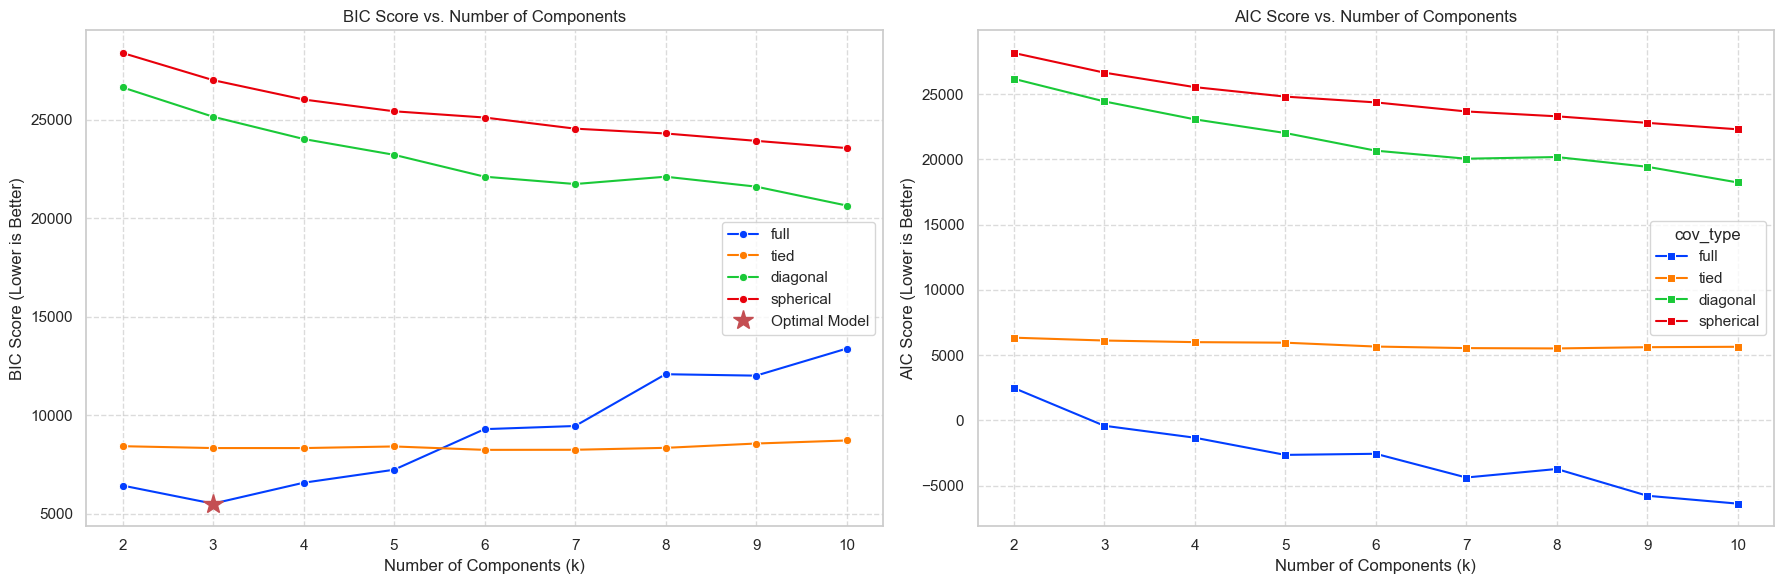

In [ ]:
def plot_ic_curves(results_df):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # 1. BIC Plot
    sns.lineplot(
        data=results_df, 
        x='n_components', 
        y='BIC', 
        hue='cov_type', 
        marker='o', 
        palette='bright',
        ax=axes[0]
    )
    axes[0].set_title('BIC Score vs. Number of Components')
    axes[0].set_ylabel('BIC Score (Lower is Better)')
    axes[0].set_xlabel('Number of Components (k)')
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Highlight the minimum BIC point
    min_bic_row = results_df.loc[results_df['BIC'].idxmin()]
    axes[0].plot(min_bic_row['n_components'], min_bic_row['BIC'], 'r*', markersize=15, label='Optimal Model')
    axes[0].legend()

    # 2. AIC Plot
    sns.lineplot(
        data=results_df, 
        x='n_components', 
        y='AIC', 
        hue='cov_type', 
        marker='s', 
        palette='bright',
        ax=axes[1]
    )
    axes[1].set_title('AIC Score vs. Number of Components')
    axes[1].set_ylabel('AIC Score (Lower is Better)')
    axes[1].set_xlabel('Number of Components (k)')
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Generate the plots using your results DataFrame
plot_ic_curves(exp2_results)

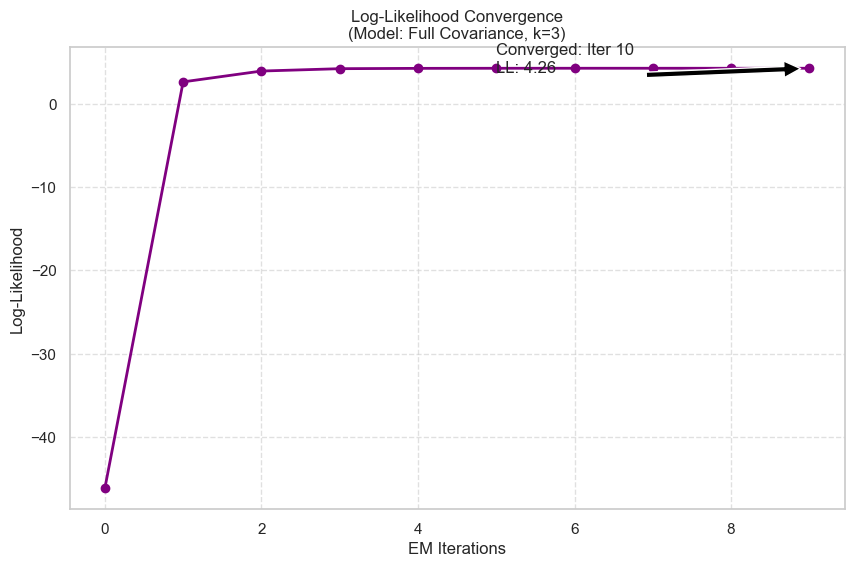

In [11]:
def plot_convergence(gmm_model):
    """Plots the log-likelihood history of the best model."""
    plt.figure(figsize=(10, 6))
    
    # Plot history
    plt.plot(gmm_model.log_likelihood_history, marker='o', linestyle='-', color='purple', linewidth=2)
    
    plt.title(f'Log-Likelihood Convergence\n(Model: {gmm_model.cov_type.capitalize()} Covariance, k={gmm_model.n_components})')
    plt.xlabel('EM Iterations')
    plt.ylabel('Log-Likelihood')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Annotate the final iteration
    final_iter = len(gmm_model.log_likelihood_history)
    final_ll = gmm_model.log_likelihood_history[-1]
    plt.annotate(f'Converged: Iter {final_iter}\nLL: {final_ll:.2f}', 
                 xy=(final_iter-1, final_ll), 
                 xytext=(final_iter-5, final_ll-0.5),
                 arrowprops=dict(facecolor='black', shrink=0.05))
    
    plt.show()

# Generate the plot using the best_gmm object from your grid search
plot_convergence(best_gmm)

### 1. Analysis of BIC & AIC Curves

* **Covariance Type Comparison:**
* The **blue line (Full Covariance)** is consistently and significantly lower than all other types. This visually confirms that the features in the Breast Cancer dataset are highly correlated.
* The **green (Diagonal)** and **red (Spherical)** lines have much higher scores, indicating poor fit. These models assume features are independent or clusters are spherical, which is clearly not true for this biological data.
* **Conclusion:** The complexity of the "Full" covariance matrix is justified because it dramatically improves the model's likelihood.


* **Optimal Component Selection ($k$):**
* On the **BIC plot (Left)**, there is a clear minimum marked by the **red star at $k$ == 3**.
* While $k$ = 2 (Malignant/Benign) is the ground truth label count, the unsupervised GMM finds $k$ = 3 to be the most mathematically stable structure. This suggests the presence of a sub-population (e.g., a distinction between "early-stage" and "advanced" malignant tumors).
* The **AIC plot (Right)** for the full model continues to decrease as  increases. This is typical behavior for AIC, which penalizes complexity less than BIC. Since BIC shows a clear "elbow" or minimum at $k$ = 3, it is the safer metric for model selection to avoid overfitting.



### 2. Analysis of Log-Likelihood Convergence

* **Stability:** The curve is smooth and monotonically increasing, which is a theoretical guarantee of the Expectation-Maximization (EM) algorithm.
* **Speed:** The model converged very quickly, reaching stability at **Iteration 10**.
* **Phase 1 (Iter 0-1):** A massive jump in likelihood as the random centroids snap to the main data clusters.
* **Phase 2 (Iter 2-10):** Fine-tuning of the covariance matrices and mixing coefficients.
* **Phase 3 (Iter 10+):** The curve plateaus, meaning the change in log-likelihood fell below your tolerance threshold ().